In [1]:
!git clone https://github.com/MukulN7/art-kate-cv-assignment.git /content/art-kate-cv-assignment
%cd /content/art-kate-cv-assignment

Cloning into '/content/art-kate-cv-assignment'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 206 (delta 9), reused 106 (delta 6), pack-reused 96 (from 1)
Receiving objects: 100% (206/206), 171.84 MiB | 24.47 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (234/234), done.
/content/art-kate-cv-assignment


In [2]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.8 MB/s eta 0:00:00


In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: 12.8
CUDA available: True
GPU: Tesla T4


In [4]:
!pip uninstall -y onnxruntime onnxruntime-gpu
!pip install -q onnx onnxruntime-gpu==1.26.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 29.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.


In [5]:
import onnxruntime as ort

print("ONNX Runtime:", ort.__version__)
print("Available providers:", ort.get_available_providers())

ONNX Runtime: 1.26.0
Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [6]:
from pathlib import Path

print("Train images:", len(list(Path("data/train/images").glob("*"))))
print("Val images:", len(list(Path("data/val/images").glob("*"))))
print("Training script:", Path("scripts/train.py").exists())
print("Export script:", Path("scripts/export_onnx.py").exists())
print("Benchmark script:", Path("scripts/benchmark_onnx.py").exists())

Train images: 59
Val images: 15
Training script: True
Export script: True
Benchmark script: True


In [7]:
!python scripts/train.py --device 0

YOLO11n Training Configuration
  Model Checkpoint : yolo11n.pt
  Dataset YAML     : /content/art-kate-cv-assignment/data/data.yaml
  Epochs           : 50
  Image Size       : 640
  Batch Size       : 16
  Optimizer        : auto
  Seed             : 42
  Patience         : 15
  AMP Enabled      : True
  Device           : 0
  Project Dir      : /content/art-kate-cv-assignment/runs/detect
  Run Name         : yolo11n_bottle_cup
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

Loading model: yolo11n.pt...

Starting training...

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False,

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,206.169,0.50017,0.68426,0.90959,0.86371,0.66862,0.80212,0.55071,1.18634,1.39098,1.51702,0.000182,0.000182,0.000182
46,47,209.479,0.48905,0.69177,0.94556,0.85212,0.72143,0.81205,0.54279,1.19447,1.38016,1.51331,0.000149,0.000149,0.000149
47,48,212.943,0.44396,0.62669,0.93825,0.83236,0.65476,0.79865,0.54760,1.17278,1.40141,1.46815,0.000116,0.000116,0.000116
48,49,216.620,0.47519,0.61996,0.90393,0.85356,0.65476,0.78665,0.55524,1.13468,1.40208,1.43301,0.000083,0.000083,0.000083
49,50,220.347,0.43131,0.63458,0.91231,0.84284,0.66871,0.78928,0.55380,1.12051,1.40914,1.40918,0.000050,0.000050,0.000050


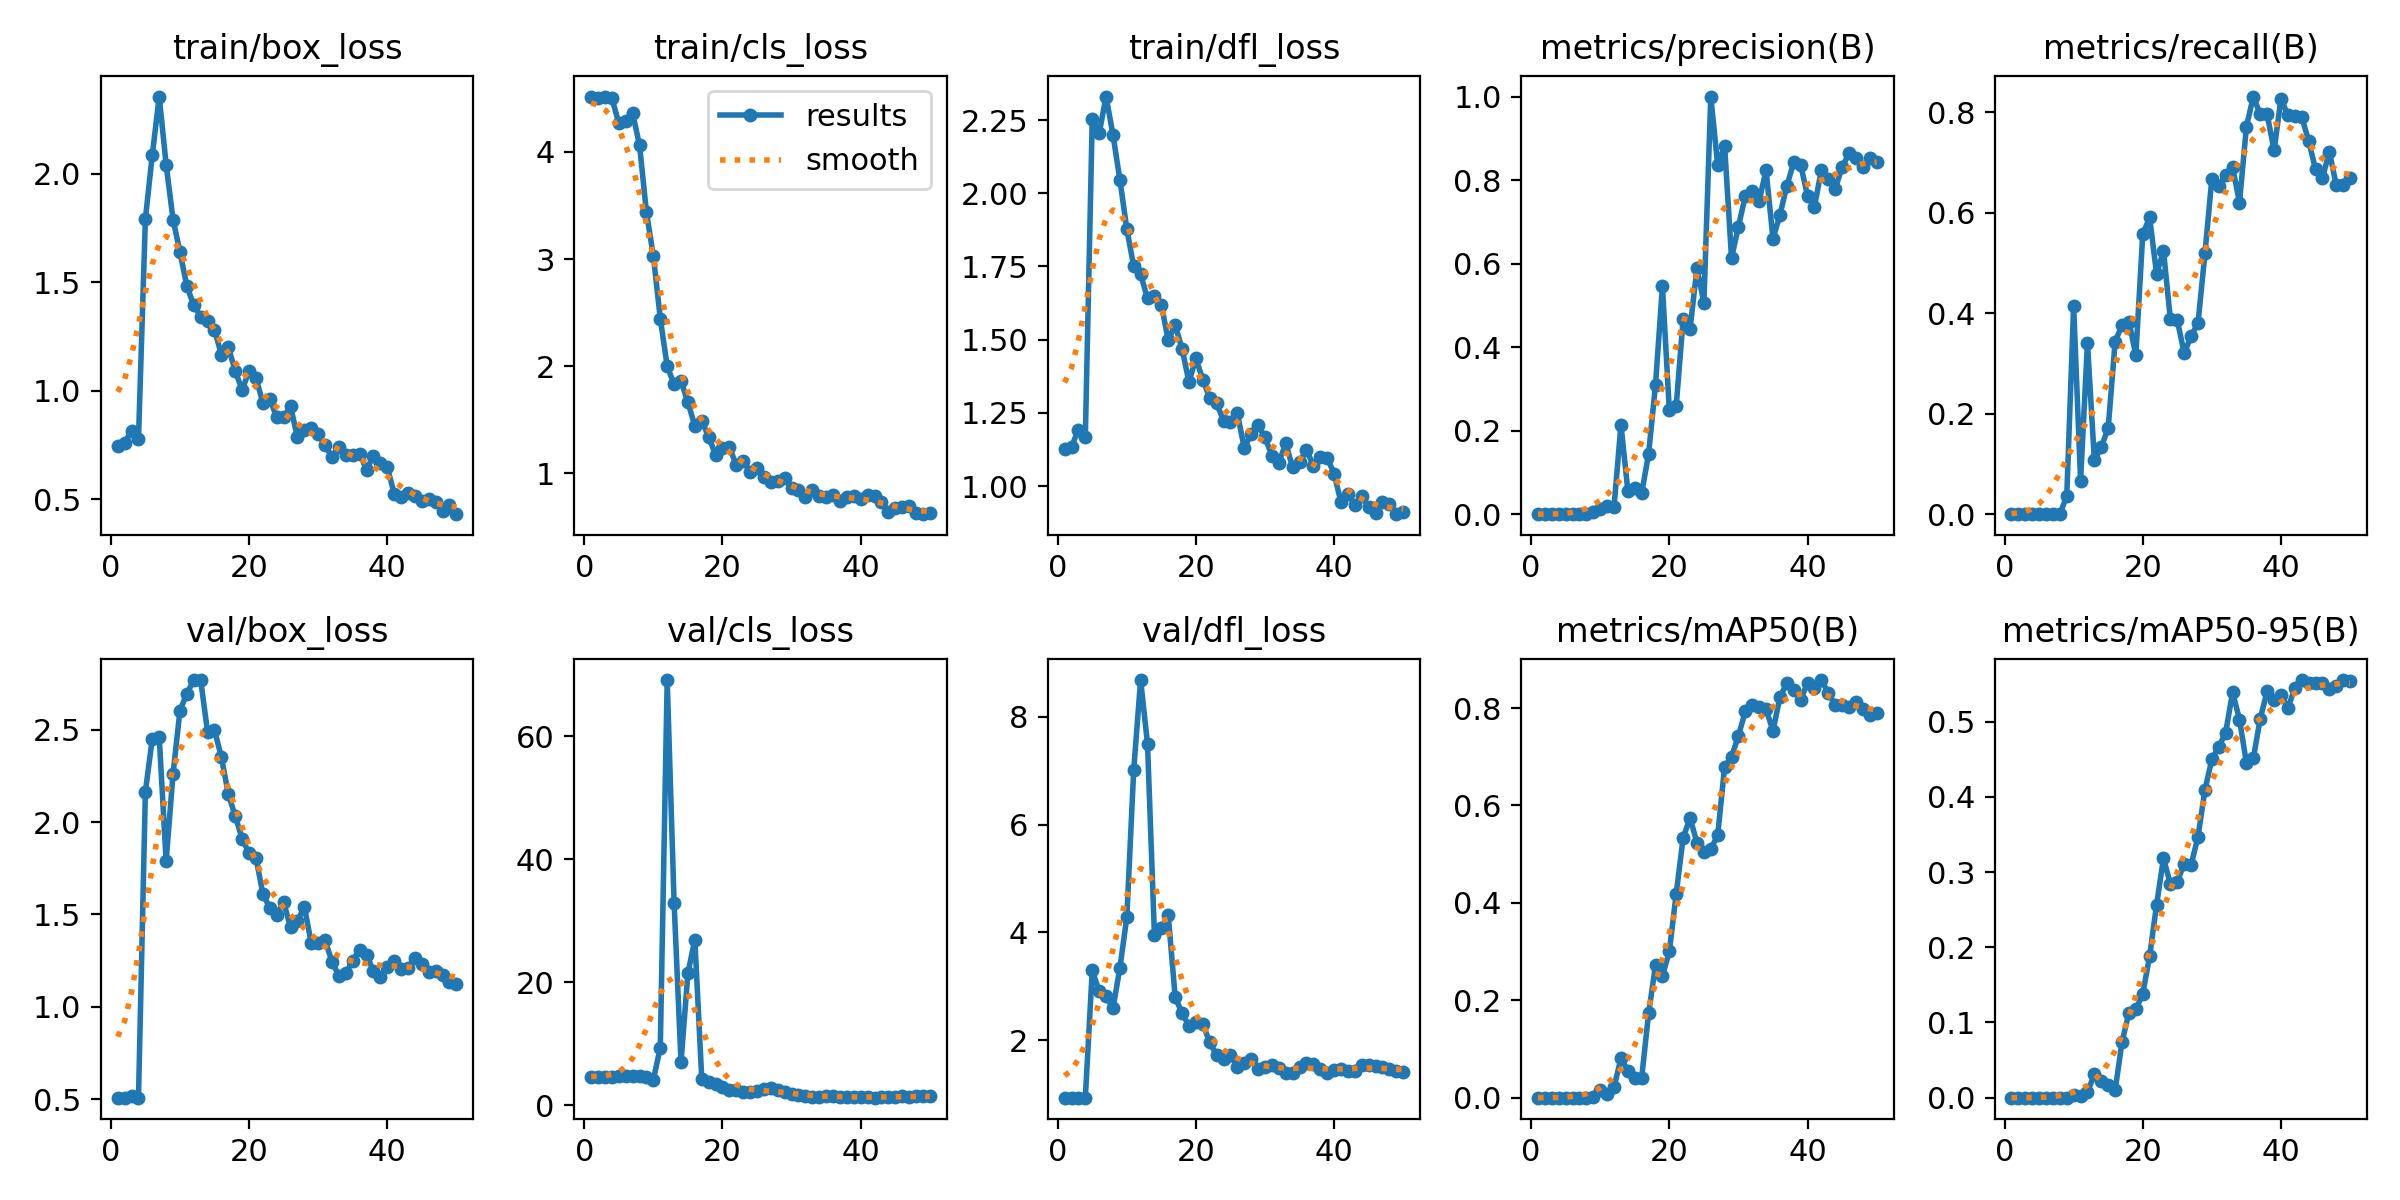

In [8]:
import pandas as pd
from IPython.display import Image, display

df = pd.read_csv("runs/detect/yolo11n_bottle_cup/results.csv")

display(df.tail())
display(Image(filename="runs/detect/yolo11n_bottle_cup/results.png"))

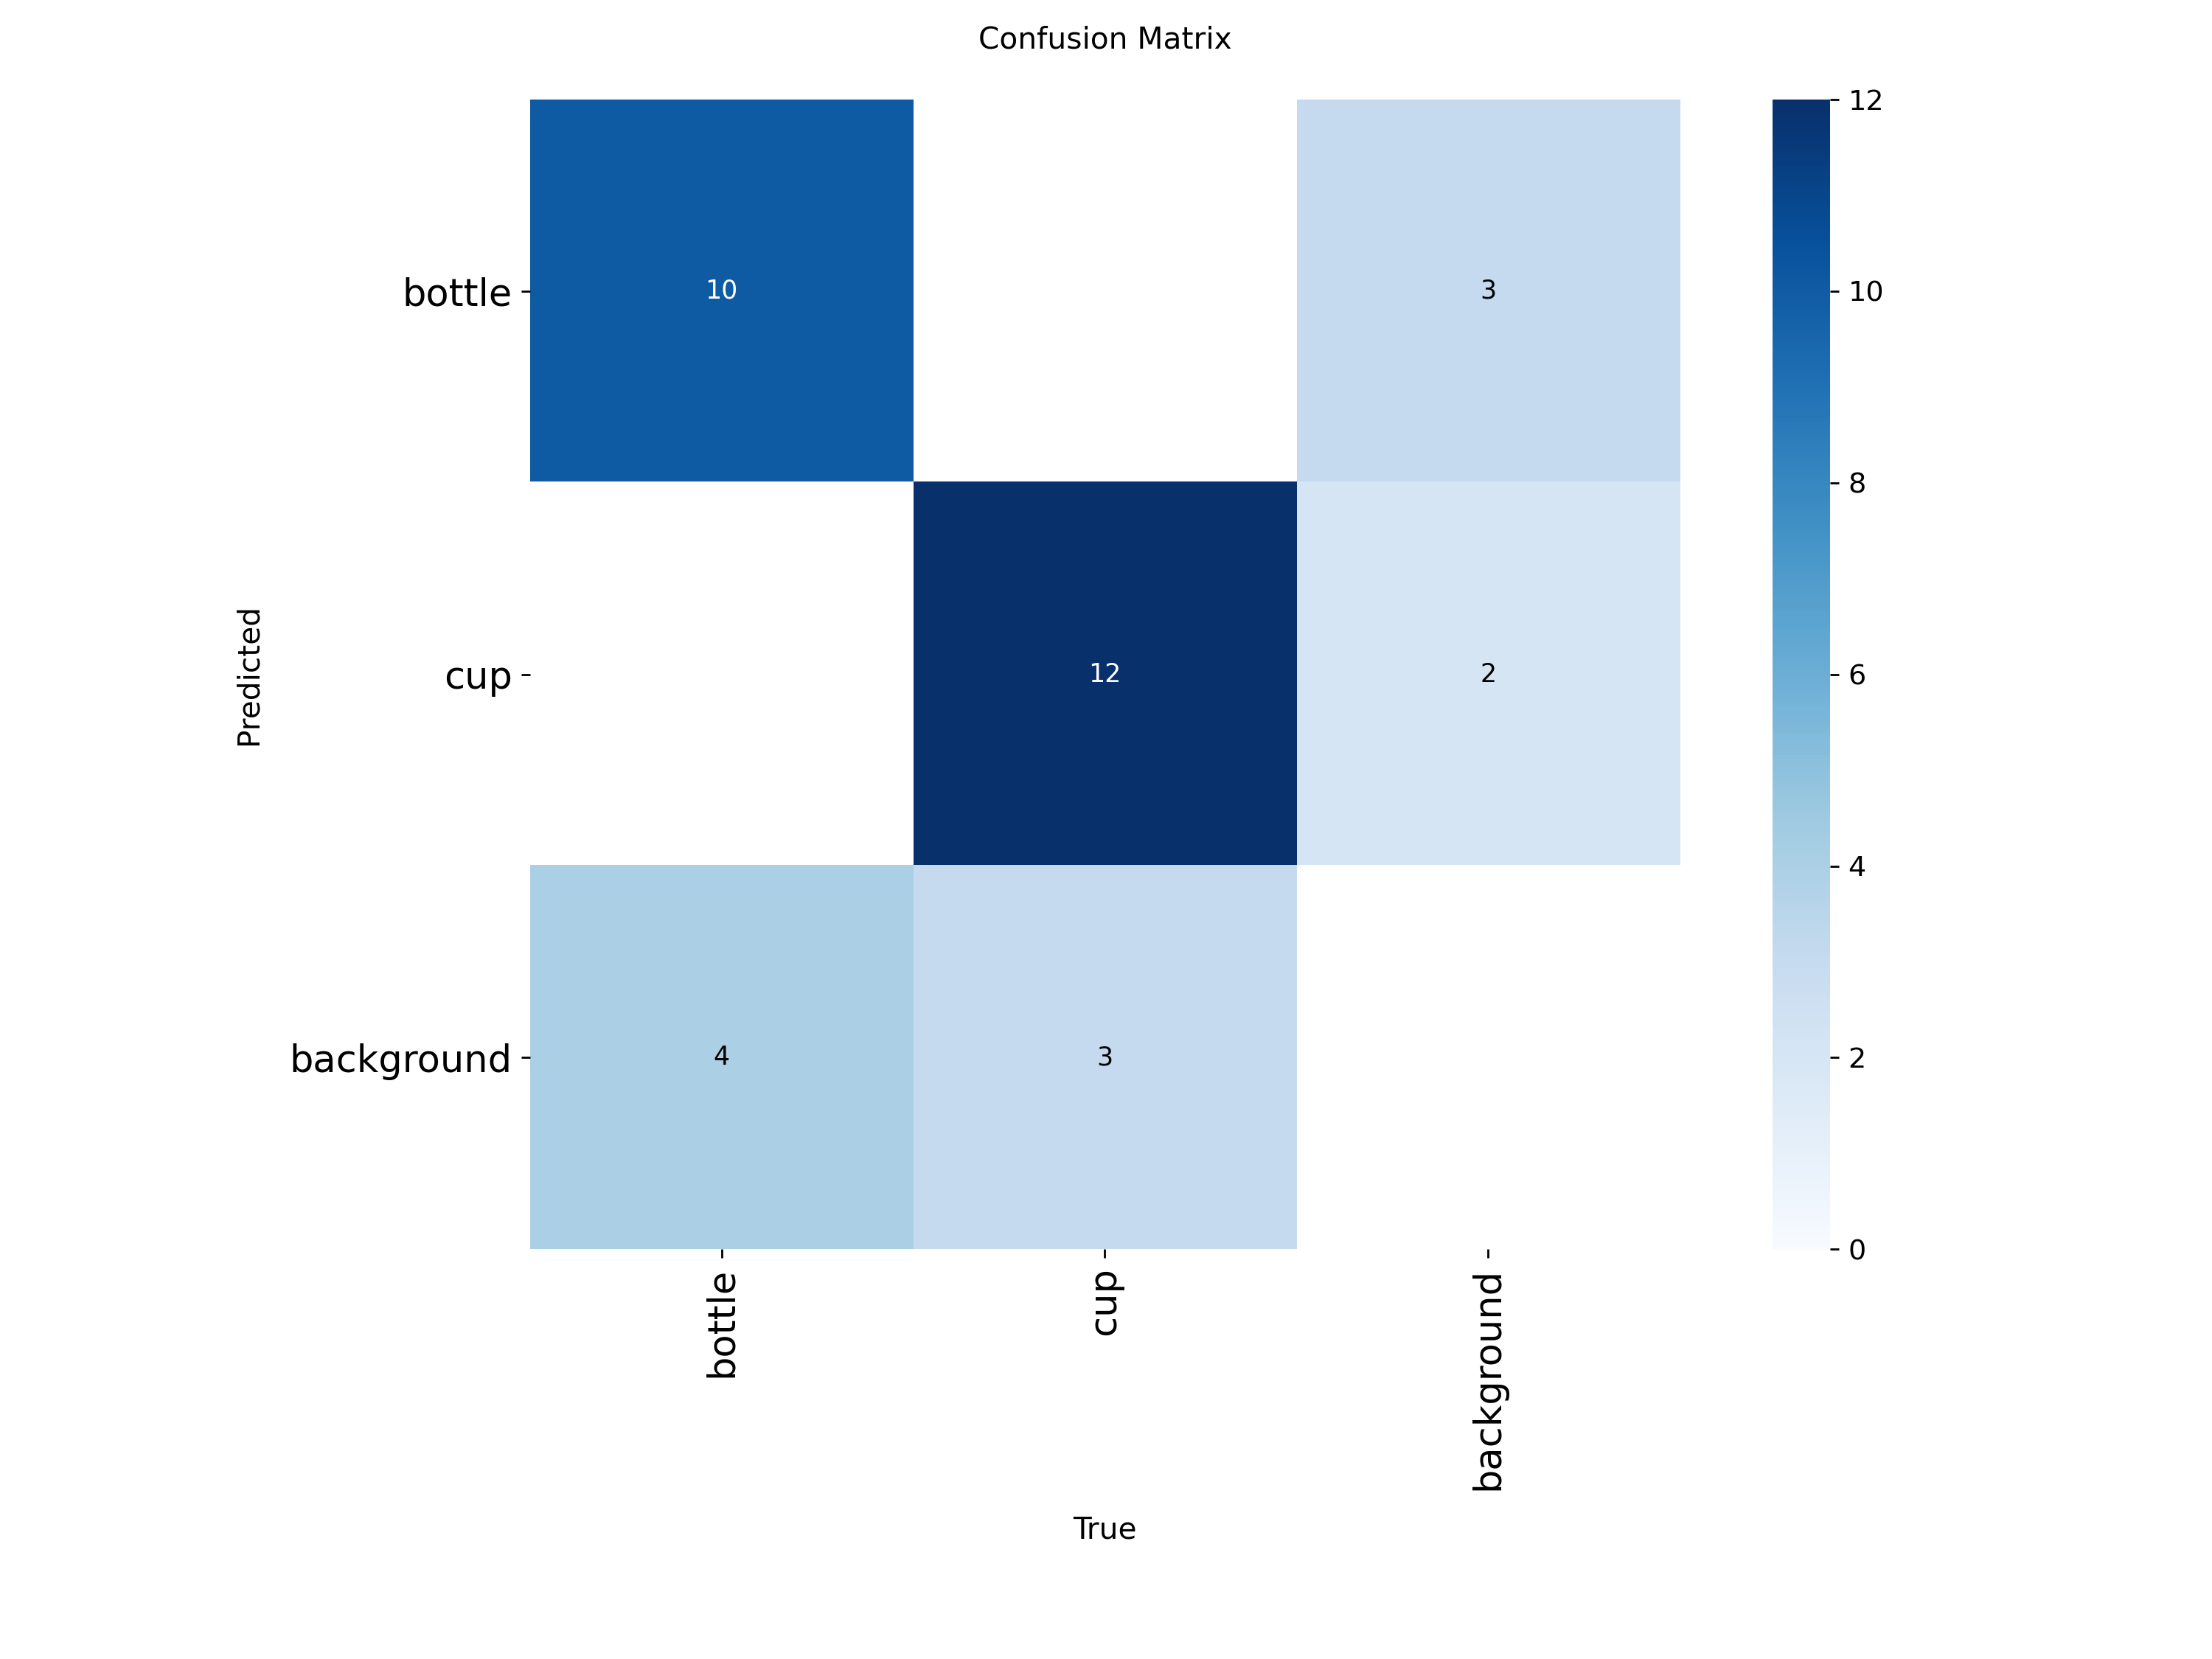

In [9]:
display(Image(filename="runs/detect/yolo11n_bottle_cup/confusion_matrix.png"))

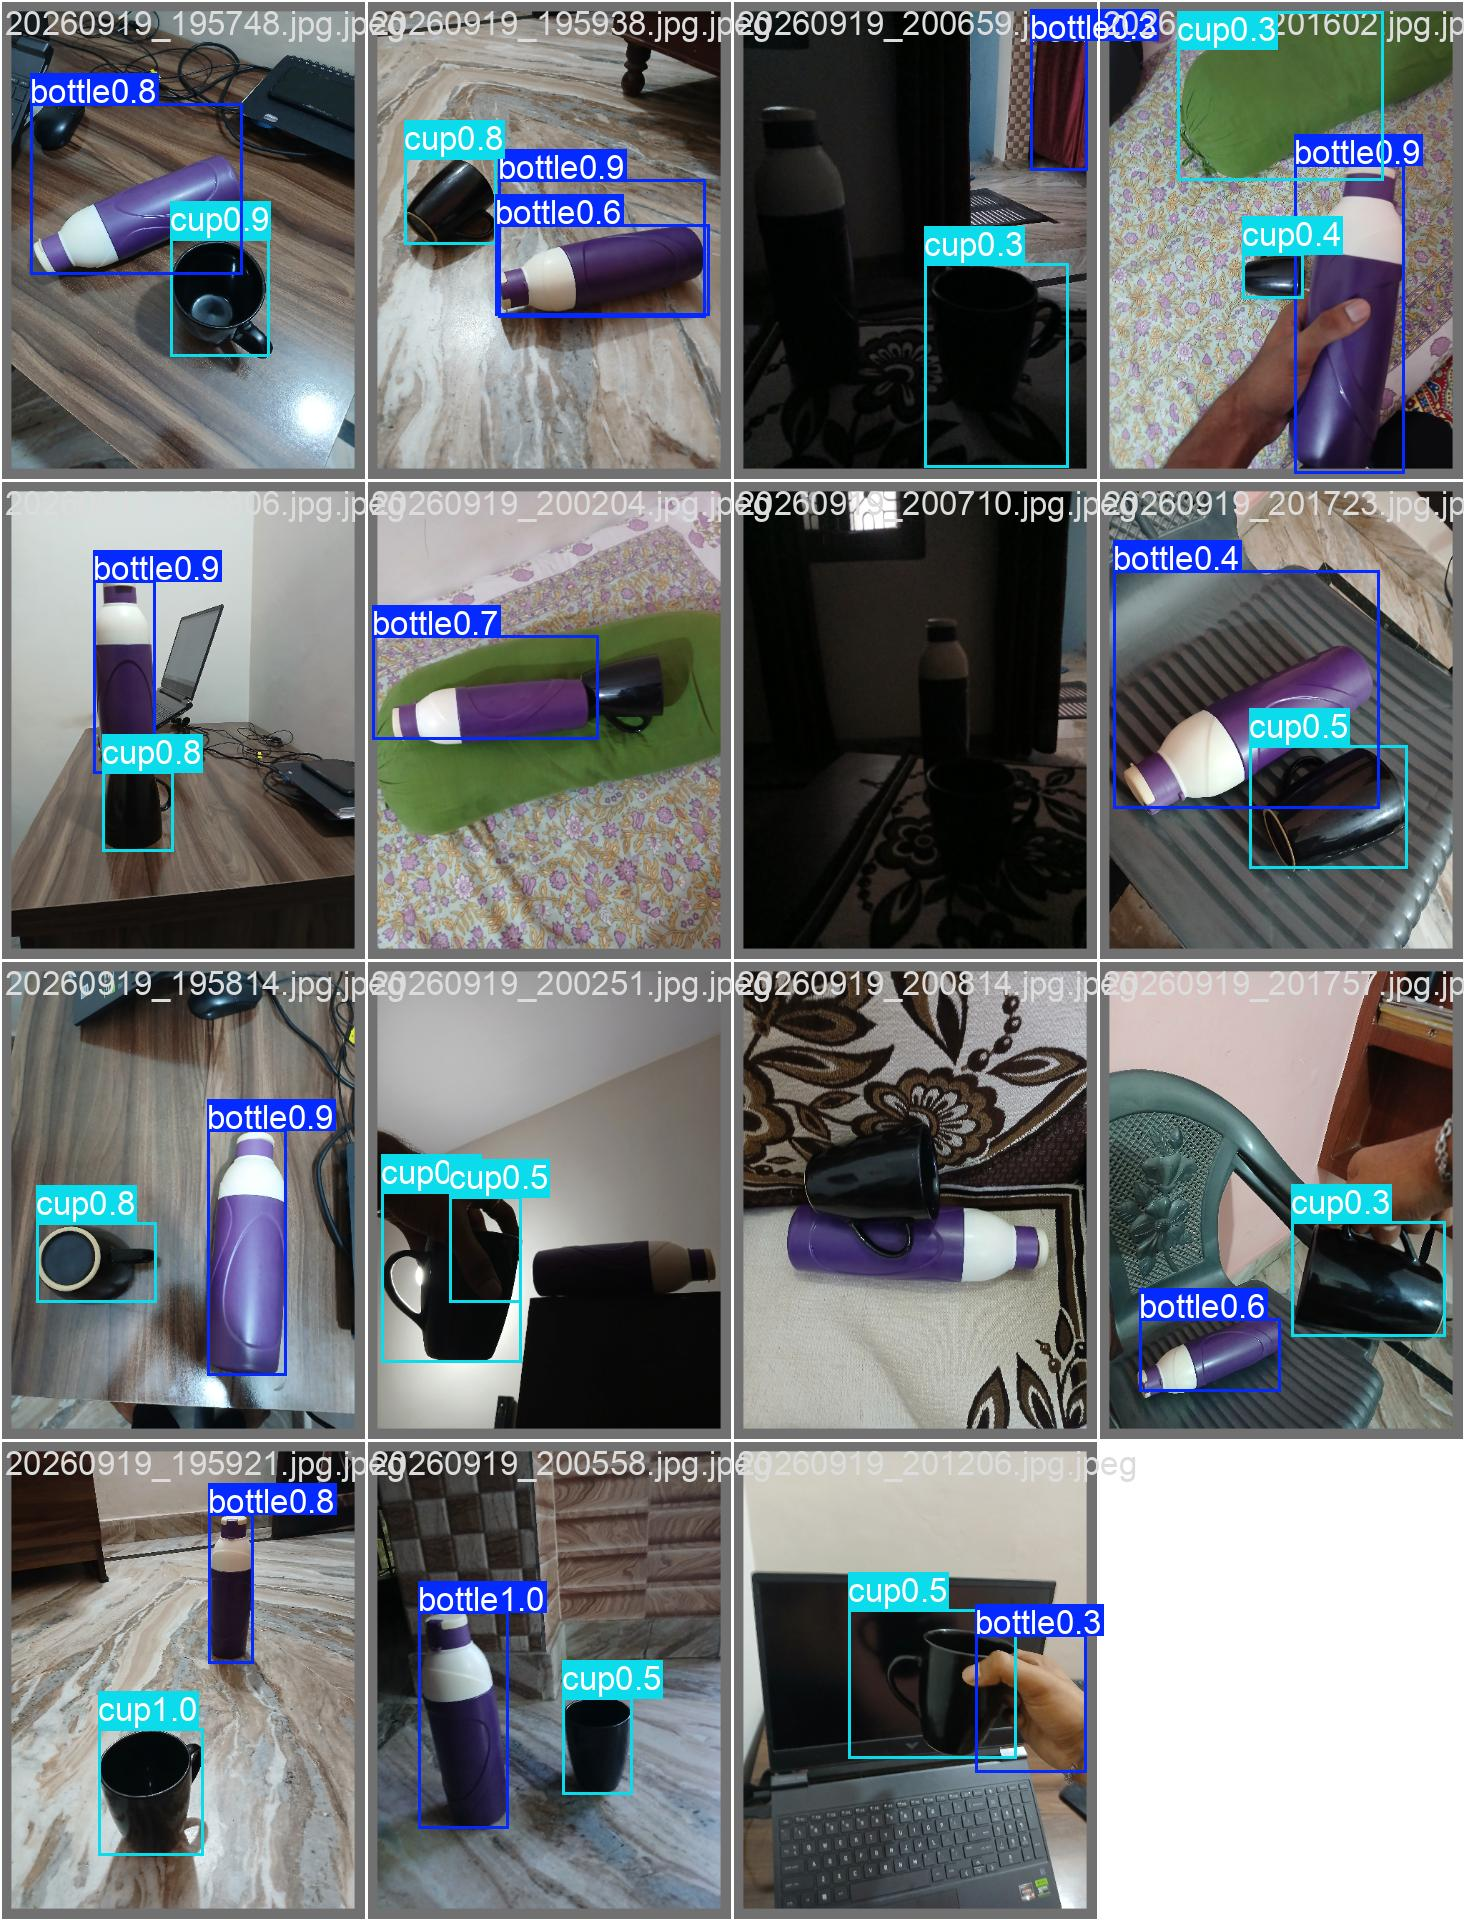

In [10]:
display(Image(filename="runs/detect/yolo11n_bottle_cup/val_batch0_pred.jpg"))

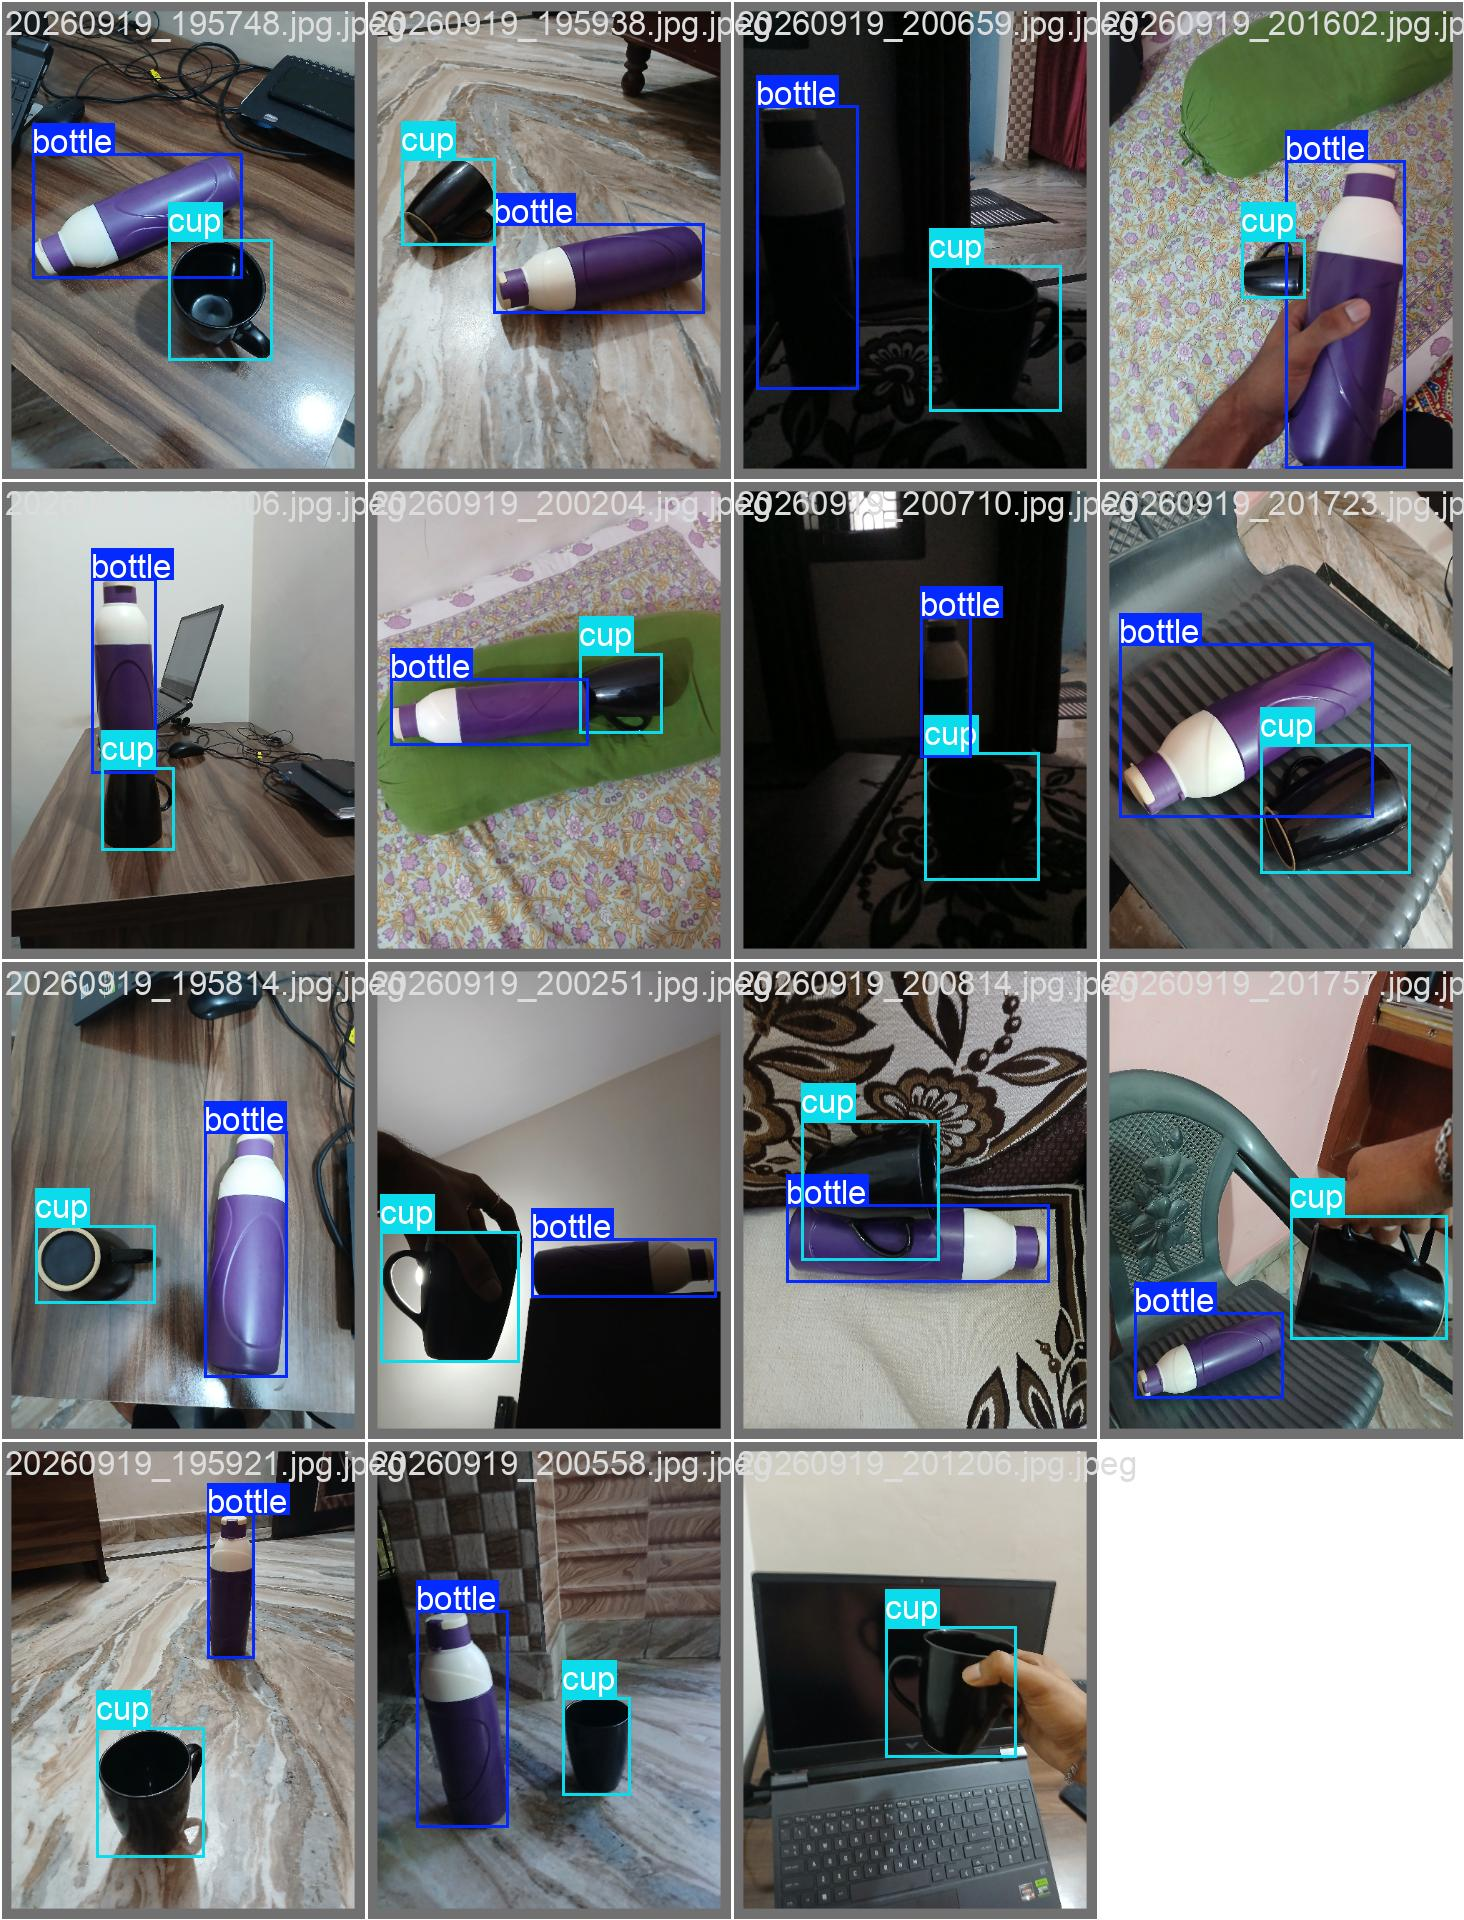

In [11]:
display(Image(filename="runs/detect/yolo11n_bottle_cup/val_batch0_labels.jpg"))

In [12]:
!python scripts/export_onnx.py

YOLO11n ONNX Export Configuration
  Weights Path : /content/art-kate-cv-assignment/runs/detect/yolo11n_bottle_cup/weights/best.pt
  Image Size   : 640x640 (Static)
  Opset        : 17
  Device       : 0
  Output Dir   : /content/art-kate-cv-assignment/runs/detect/yolo11n_bottle_cup/weights

[1/2] Exporting FP32 ONNX model...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/art-kate-cv-assignment/runs/detect/yolo11n_bottle_cup/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpd

In [13]:
from pathlib import Path

weights = Path("runs/detect/yolo11n_bottle_cup/weights")

for name in ["best.pt", "best_fp32.onnx", "best_fp16.onnx"]:
    p = weights / name
    print(f"{name}: {p.stat().st_size / (1024**2):.2f} MB")

best.pt: 5.21 MB
best_fp32.onnx: 10.11 MB
best_fp16.onnx: 5.11 MB


In [15]:
!python scripts/benchmark_onnx.py

ONNX Runtime & PyTorch Model Benchmark Suite
  [HARDWARE] CUDAExecutionProvider is available and selected.
  PyTorch Model (.pt)   : /content/art-kate-cv-assignment/runs/detect/yolo11n_bottle_cup/weights/best.pt
  FP32 ONNX Model       : /content/art-kate-cv-assignment/runs/detect/yolo11n_bottle_cup/weights/best_fp32.onnx
  FP16 ONNX Model       : /content/art-kate-cv-assignment/runs/detect/yolo11n_bottle_cup/weights/best_fp16.onnx
  Dataset Config        : /content/art-kate-cv-assignment/data/data.yaml
  Warmup Iterations     : 10
  Benchmark Iterations  : 100

--- Benchmarking: PyTorch (FP32) ---
  File Size          : 5.21 MB
  Evaluating validation metrics (Precision, Recall, mAP)...
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2683.9±1498.4 MB/s, size: 5916.0 KB)
val: Scanning /content/art-kate-cv-assignment/dat

In [19]:
from pathlib import Path
from ultralytics import YOLO

pt_path = Path("runs/detect/yolo11n_bottle_cup/weights/best.pt")
fp32_path = Path("runs/detect/yolo11n_bottle_cup/weights/best_fp32.onnx")
fp16_path = Path("runs/detect/yolo11n_bottle_cup/weights/best_fp16.onnx")

val_images = sorted(
    p for p in Path("data/val/images").glob("*")
    if p.suffix.lower() in (".jpg", ".jpeg", ".png")
)

pt_model = YOLO(str(pt_path))

# Select first validation image with at least one PyTorch detection
selected_img = None

for img in val_images:
    result = pt_model.predict(
        source=str(img),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )[0]

    if len(result.boxes) > 0:
        selected_img = img
        break

print("Selected validation image:", selected_img.name)

# Run the same image through all three models
pt_result = pt_model.predict(
    source=str(selected_img),
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)[0]

fp32_model = YOLO(str(fp32_path))
fp16_model = YOLO(str(fp16_path))

fp32_result = fp32_model.predict(
    source=str(selected_img),
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)[0]

fp16_result = fp16_model.predict(
    source=str(selected_img),
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)[0]

print("\nDetection counts:")
print("PyTorch FP32:", len(pt_result.boxes))
print("ONNX FP32:", len(fp32_result.boxes))
print("ONNX FP16:", len(fp16_result.boxes))

def compare(a, b, name):
    print(f"\n{name}")

    if len(a.boxes) == 0 or len(b.boxes) == 0:
        print("Cannot compare coordinates because one model has no detections.")
        return

    n = min(len(a.boxes), len(b.boxes))

    box_diff = (
        a.boxes.xyxy[:n].cpu().numpy()
        - b.boxes.xyxy[:n].cpu().numpy()
    )
    conf_diff = (
        a.boxes.conf[:n].cpu().numpy()
        - b.boxes.conf[:n].cpu().numpy()
    )

    classes_a = a.boxes.cls[:n].cpu().numpy()
    classes_b = b.boxes.cls[:n].cpu().numpy()

    print("Compared detections:", n)
    print("Max Box Coordinate Diff:", abs(box_diff).max(), "px")
    print("Max Confidence Diff:", abs(conf_diff).max())
    print("Class Predictions Match:", (classes_a == classes_b).all())

compare(pt_result, fp32_result, "PyTorch vs ONNX FP32")
compare(pt_result, fp16_result, "PyTorch vs ONNX FP16")

Selected validation image: 20260919_195748.jpg.jpeg
Loading runs/detect/yolo11n_bottle_cup/weights/best_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider
Loading runs/detect/yolo11n_bottle_cup/weights/best_fp16.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider

Detection counts:
PyTorch FP32: 2
ONNX FP32: 2
ONNX FP16: 2

PyTorch vs ONNX FP32
Compared detections: 2
Max Box Coordinate Diff: 60.539146 px
Max Confidence Diff: 0.06586206
Class Predictions Match: True

PyTorch vs ONNX FP16
Compared detections: 2
Max Box Coordinate Diff: 59.878075 px
Max Confidence Diff: 0.06570673
Class Predictions Match: True


In [20]:
from pathlib import Path

root = Path(".")
weights = root / "runs/detect/yolo11n_bottle_cup/weights"
run_dir = root / "runs/detect/yolo11n_bottle_cup"

artifacts = [
    weights / "best.pt",
    weights / "best_fp32.onnx",
    weights / "best_fp16.onnx",
    run_dir / "results.csv",
    run_dir / "results.png",
    run_dir / "confusion_matrix.png",
    run_dir / "val_batch0_pred.jpg",
    run_dir / "val_batch0_labels.jpg",
]

print("IMPORTANT ARTIFACTS")
print("=" * 60)

for path in artifacts:
    if path.exists():
        print(f"FOUND  {path}  ({path.stat().st_size / (1024**2):.2f} MB)")
    else:
        print(f"MISSING {path}")

IMPORTANT ARTIFACTS
FOUND  runs/detect/yolo11n_bottle_cup/weights/best.pt  (5.21 MB)
FOUND  runs/detect/yolo11n_bottle_cup/weights/best_fp32.onnx  (10.11 MB)
FOUND  runs/detect/yolo11n_bottle_cup/weights/best_fp16.onnx  (5.11 MB)
FOUND  runs/detect/yolo11n_bottle_cup/results.csv  (0.01 MB)
FOUND  runs/detect/yolo11n_bottle_cup/results.png  (0.28 MB)
FOUND  runs/detect/yolo11n_bottle_cup/confusion_matrix.png  (0.09 MB)
FOUND  runs/detect/yolo11n_bottle_cup/val_batch0_pred.jpg  (0.42 MB)
FOUND  runs/detect/yolo11n_bottle_cup/val_batch0_labels.jpg  (0.42 MB)


In [21]:
!rm -f yolo11n_bottle_cup_backup.zip
!zip -r -q yolo11n_bottle_cup_backup.zip \
    runs/detect/yolo11n_bottle_cup \
    data/data.yaml \
    scripts/train.py \
    scripts/export_onnx.py \
    scripts/benchmark_onnx.py \
    requirements.txt

from pathlib import Path

backup = Path("yolo11n_bottle_cup_backup.zip")
print(f"Backup created: {backup}")
print(f"Size: {backup.stat().st_size / (1024**2):.2f} MB")

Backup created: yolo11n_bottle_cup_backup.zip
Size: 26.94 MB


In [22]:
from google.colab import files

files.download("yolo11n_bottle_cup_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
from google.colab import files

files.download("runs/detect/yolo11n_bottle_cup/weights/best.pt")
files.download("runs/detect/yolo11n_bottle_cup/weights/best_fp32.onnx")
files.download("runs/detect/yolo11n_bottle_cup/weights/best_fp16.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files

for path in [
    "runs/detect/yolo11n_bottle_cup/results.csv",
    "runs/detect/yolo11n_bottle_cup/results.png",
    "runs/detect/yolo11n_bottle_cup/confusion_matrix.png",
    "runs/detect/yolo11n_bottle_cup/val_batch0_pred.jpg",
    "runs/detect/yolo11n_bottle_cup/val_batch0_labels.jpg",
]:
    files.download(path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>